In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
from pathlib import Path
#import pathlib as Path

import sys
import pandas as pd
from tqdm import tqdm

from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader

from dataclasses import dataclass
from typing import Tuple, Dict, Optional



KAGGLE_MODEL_DIR = Path("./Kaggle/Kaggle_run_final")   # change this to your real folder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Model classes

In [47]:

#=======================================================================
# VAE classes
#=======================================================================
class VAE(nn.Module):
    """
    Standard Variational Autoencoder using Linear (Fully Connected) layers.
    """
    def __init__(self, input_dim=784, hidden_channels=400, latent_dim=32):
        super(VAE, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_channels = hidden_channels
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_channels) #input to hidden
        self.enc_fc2 = nn.Linear(hidden_channels, hidden_channels) #hidden to hidden

        # the encoder outputs the mean and log variance for the latent space
        self.enc_mean = nn.Linear(hidden_channels, latent_dim) #hidden to mean
        self.enc_logvar = nn.Linear(hidden_channels, latent_dim) #hidden to logvar

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_channels) #latent to hidden
        self.dec_fc2 = nn.Linear(hidden_channels, hidden_channels) #hidden to hidden
        self.dec_output = nn.Linear(hidden_channels, input_dim) #hidden to output

        self.leaky_relu = nn.LeakyReLU(0.2) #LeakyReLU activation function


    def encode(self, x):
        """Encodes the input into the latent space, returning the mean and log variance."""
        h = self.leaky_relu(self.fc1(x))
        h = self.leaky_relu(self.enc_fc2(h))
        mean = self.enc_mean(h)
        logvar = self.enc_logvar(h)
        return mean, logvar
    
    def reparameterize(self, mean, logvar):
        """Applies reparameterization trick z = mean + std * eps, where eps ~ N(0, 1)
        This allows backpropagation through the stochastic sampling process."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
    

    def decode(self, z):
        """Decodes the latent variable back to the input space."""
        h = self.leaky_relu(self.dec_fc1(z))
        h = self.leaky_relu(self.dec_fc2(h))
        x_hat = torch.sigmoid(self.dec_output(h)) #sigmoid to get output in [0, 1]
        return x_hat
    
    def forward(self, x):
        # Flatten the input image to a vector
        BATCH_SIZE, C, H, W = x.size() #C = channels, H = height, W = width
        x_flat = x.view(BATCH_SIZE, -1) # Flatten the image to a vector

        # Encode the input to get mean and log variance
        mean, logvar = self.encode(x_flat)

        # Sample from the distribution using the reparameterization trick
        z = self.reparameterize(mean, logvar)

        # Decode the latent variable to reconstruct the input
        x_hat = self.decode(z)

        #reshape the output back to the original image shape
        x_hat = x_hat.view(BATCH_SIZE, C, H, W)
        return x_hat, mean, logvar


class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder for complex image datasets.
    """
    def __init__(self, in_channels, input_size, latent_dim=128, dataset_name="mnist"):
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # ==========================================
        # 1. Input Size Type-Check
        # ==========================================
        # If your dataloader returns an int (e.g., 28), convert it to (28, 28)
        if isinstance(input_size, int):
            self.img_height = input_size
            self.img_width = input_size
        else:
            self.img_height = input_size[0]
            self.img_width = input_size[1]


        # ==========================================
        # ENCODER (Conv2d downsamples the image)
        # ==========================================
        # Formula for output size: [(W - Kernel + 2*Pad) / Stride] + 1
        self.enc_conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        # --- Dynamic Dimension Calculation ---
        # We pass a dummy tensor of the correct shape through the conv layers 
        # to figure out exactly how many features we need to flatten!
        dummy_x = torch.zeros(1, in_channels, self.img_height, self.img_width)
        dummy_out = self.enc_conv2(self.enc_conv1(dummy_x))
        
        # Save the shape before flattening so the decoder knows how to unflatten it later
        self.conv_shape = dummy_out.shape[1:] 
        self.flattened_size = dummy_out.numel()
        # -------------------------------------
        
        # Latent space mappings
        self.enc_mean = nn.Linear(self.flattened_size, latent_dim)
        self.enc_logvar = nn.Linear(self.flattened_size, latent_dim)
        
        # ==========================================
        # DECODER (ConvTranspose2d upsamples the image)
        # ==========================================
        self.dec_fc = nn.Linear(latent_dim, self.flattened_size)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        h = self.leaky_relu(self.enc_conv1(x))
        h = self.leaky_relu(self.enc_conv2(h))
        
        # Flatten for the linear layer
        h_flat = h.view(h.size(0), -1)
        mean = self.enc_mean(h_flat)
        logvar = self.enc_logvar(h_flat)
        return mean, logvar
        
    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
        
    def decode(self, z):
        # 1. Map latent vector back to the flattened spatial size
        h = self.leaky_relu(self.dec_fc(z))
        
        # 2. Reshape back to 3D tensor (Channels, Height, Width)
        h = h.view(h.size(0), *self.conv_shape)
        
        # 3. Upsample back to original image size
        h = self.leaky_relu(self.dec_conv1(h))
        
        # No ReLU on the final output, use Sigmoid (for MNIST/Fashion) or Tanh (if CIFAR is normalized -1 to 1)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_conv2(h))
        else:
            x_hat =  self.dec_conv2(h)#torch.sigmoid(self.dec_conv2(h))
        return x_hat

    def forward(self, x):
        # Notice we NO LONGER flatten the input 'x' here! It stays as a 2D image.
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_hat = self.decode(z)
        
        return x_hat, mean, logvar

#=======================================================================
# VQ-VAE classes
#=======================================================================

@dataclass
class VQLossOutput:
    loss: torch.Tensor
    codebook_loss: torch.Tensor
    commitment_loss: torch.Tensor
    perplexity: torch.Tensor

class EncoderVQ(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels * 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)

class DecoderVQ(nn.Module):
    def __init__(self, latent_dim=256, hidden_channels=128, out_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_channels * 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),  # matches normalized inputs in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)   

class VQVAE(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256, code_book_size=512, commitment_cost=0.25):
        super().__init__()

        self.encoder = EncoderVQ(in_channels=in_channels, hidden_channels=hidden_channels, latent_dim=latent_dim)
        self.vq = VectorQuantizer(code_book_size=code_book_size,embedding_dim=latent_dim,commitment_cost=commitment_cost)
        self.decoder = DecoderVQ(latent_dim=latent_dim, hidden_channels=hidden_channels, out_channels=in_channels)

    def encode(self, x):
        z = self.encoder(x)
        vq_loss, quantized, encoding_indices = self.vq(z)
        return vq_loss, quantized, encoding_indices

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        vq_loss, quantized, encoding_indices = self.encode(x)
        recon = self.decode(quantized)
        return recon, vq_loss, quantized, encoding_indices
    



class VectorQuantizer(nn.Module):
    def __init__(self, code_book_size=512, embedding_dim=256, commitment_cost=0.25):
        super().__init__()
        self.code_book_size = code_book_size
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(self.code_book_size, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / self.code_book_size, 1 / self.code_book_size)

    def forward(self, z):
        z = z.permute(0, 2, 3, 1).contiguous()
        z_shape = z.shape
        z_flattened = z.view(-1, self.embedding_dim)

        distances = (
            z_flattened.pow(2).sum(dim=1, keepdim=True)
            - 2 * z_flattened @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(dim=1)
        )

        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.embedding(encoding_indices).view(z_shape)

        commitment_loss = F.mse_loss(quantized.detach(), z)
        codebook_loss = F.mse_loss(quantized, z.detach())
        vq_loss = codebook_loss + self.commitment_cost * commitment_loss

        quantized = z + (quantized - z).detach()
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        encoding_indices = encoding_indices.view(z_shape[0], z_shape[1], z_shape[2])

        encodings_onehot = F.one_hot(
            encoding_indices.view(-1),
            num_classes=self.code_book_size
        ).float()
        avg_probs = encodings_onehot.mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        return VQLossOutput(
            loss=vq_loss,
            codebook_loss=codebook_loss,
            commitment_loss=commitment_loss,
            perplexity=perplexity
        ), quantized, encoding_indices


# VAE analysis functions

These are duplicates of the functions from the VAE and VQVAE notebooks


## Graph and results functions


In [44]:
# Plotting functions 
def plot_vae_history(history):
    """
    Plots the training curves for Total Loss, BCE, and KLD.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Subplot 1: Total Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Total Loss', color='blue'),# marker='o')
    plt.title("VAE Total Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Subplot 2: BCE and KLD Breakdown
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['bce_loss'], label='Reconstruction (BCE)', color='green') #, marker='s')
    plt.plot(epochs, history['kld_loss'], label='KL Divergence', color='red')#, marker='^')
    plt.title("Loss Components Breakdown")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def generate_vae_images(model, num_images=16, device='cpu'):
    """
    Sample latent vectors and decode them to images for MNIST/Fashion-MNIST/CIFAR-10.
    Works with decoders that return either flattened tensors [B, D] or image tensors [B, C, H, W].
    """
    model.eval()
    z_random = torch.randn(num_images, model.latent_dim).to(device)

    with torch.no_grad():
        generated = model.decode(z_random)

        if generated.ndim == 4:
            # Decoder already returned [B, C, H, W] (e.g., ConvVAE).
            generated_images = generated
        elif generated.ndim == 2:
            # Decoder returned flattened outputs [B, D] (e.g., FC VAE).
            dataset_name = getattr(model, "dataset_name", "mnist").lower()
            in_channels = 3 if dataset_name == "cifar10" else 1

            if hasattr(model, "img_height") and hasattr(model, "img_width"):
                h, w = model.img_height, model.img_width
            else:
                flat_dim = generated.size(1)
                pixels_per_channel = flat_dim // in_channels
                side = int(np.sqrt(pixels_per_channel))
                if side * side * in_channels != flat_dim:
                    raise ValueError(
                        f"Cannot infer image shape from flattened decoder output with dim={flat_dim}."
                    )
                h, w = side, side

            generated_images = generated.view(num_images, in_channels, h, w)
        else:
            raise ValueError(
                f"Unexpected decoder output shape {tuple(generated.shape)}. Expected 2D or 4D tensor."
            )

    nrow = max(1, int(np.sqrt(num_images)))
    grid = vutils.make_grid(generated_images.cpu(), nrow=nrow, padding=2)

    plt.figure(figsize=(6, 6))
    if generated_images.size(1) == 1:
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.title("Generated Images from Latent Space")
    plt.axis("off")
    plt.show()

def plot_2d_latent_space(model, test_loader, device, num_batches=15):
    """
    Plots the 2D latent space directly without needing t-SNE.
    """
    model.eval()
    latent_x = []
    latent_y = []
    labels = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(test_loader):
            if i >= num_batches: break
            
            data_flat = data.view(data.size(0), -1).to(device)
            mean, _ = model.encode(data_flat)
            
            # Extract z0 and z1 directly
            latent_x.extend(mean[:, 0].cpu().numpy())
            latent_y.extend(mean[:, 1].cpu().numpy())
            labels.extend(target.numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_x, latent_y, c=labels, cmap='tab10', alpha=0.7, s=15)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Digit Class')
    
    plt.title("Direct 2D Latent Space Map")
    plt.xlabel("Latent Dimension 1 ($z_0$)")
    plt.ylabel("Latent Dimension 2 ($z_1$)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

### load vae

In [ ]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, torch.Tensor):
        if obj.ndim == 0:
            return obj.item()
        return obj.detach().cpu().tolist()
    else:
        return obj




def save_trained_vae(
    model,
    optimizer,
    history,
    save_dir="./saved_models",
    run_name="vae_run",
    model_config=None,
    best_model_state_dict=None,
    extra_info=None,
):
    save_dir = Path.Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = save_dir / f"{run_name}.pt"
    history_path = save_dir / f"{run_name}_history.json"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "best_model_state_dict": best_model_state_dict,
        "history": history,
        "model_config": model_config if model_config is not None else {},
        "extra_info": extra_info if extra_info is not None else {},
    }

    torch.save(checkpoint, checkpoint_path)

    # remove non-JSON-safe objects from history export
    history_json = {
        k: v for k, v in history.items()
        if k not in ["model", "optimizer"]
    }

    with open(history_path, "w") as f:
        json.dump(
            {
                "history": make_json_safe(history_json),
                "model_config": make_json_safe(model_config if model_config is not None else {}),
                "extra_info": make_json_safe(extra_info if extra_info is not None else {}),
            },
            f,
            indent=2,
        )

    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history json to: {history_path}")

    return str(checkpoint_path), str(history_path)


import inspect

def load_trained_vae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model_config = checkpoint.get("model_config", {})

    # keep only args accepted by model_class.__init__
    valid_params = inspect.signature(model_class.__init__).parameters
    filtered_model_config = {
        k: v for k, v in model_config.items()
        if k in valid_params and k != "self"
    }

    model = model_class(**filtered_model_config).to(device)

    if load_best and checkpoint.get("best_model_state_dict") is not None:
        model.load_state_dict(checkpoint["best_model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": model_config,
        "extra_info": extra_info,
    }


# def load_trained_vae(
#     checkpoint_path,
#     model_class,
#     device="cpu",
#     load_best=False,
# ):
#     checkpoint = torch.load(
#         checkpoint_path,
#         map_location=device,
#         weights_only=False,
#     )

#     model_config = checkpoint.get("model_config", {})
#     model = model_class(**model_config).to(device)

#     if load_best and checkpoint.get("best_model_state_dict") is not None:
#         model.load_state_dict(checkpoint["best_model_state_dict"])
#     else:
#         model.load_state_dict(checkpoint["model_state_dict"])

#     optimizer_state = checkpoint.get("optimizer_state_dict", None)
#     history = checkpoint.get("history", {})
#     extra_info = checkpoint.get("extra_info", {})

#     return {
#         "model": model,
#         "optimizer_state_dict": optimizer_state,
#         "history": history,
#         "model_config": model_config,
#         "extra_info": extra_info,
#     }



## fetch VAE models


In [40]:
vae_checkpoint_path = Path(str(KAGGLE_MODEL_DIR / "VAE_final"/ "saved_models/VAE"))

vae_mnist_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "MNIST" / "vae_mnist_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_mnist_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "MNIST" / "vae_mnist_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_fmnist_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "FMNIST" / "vae_fashionmnist_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_fmnist_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "FMNIST" / "vae_fashionmnist_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "CIFAR" / "vae_cifar10_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "CIFAR" / "vae_cifar10_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

## Graphs and results

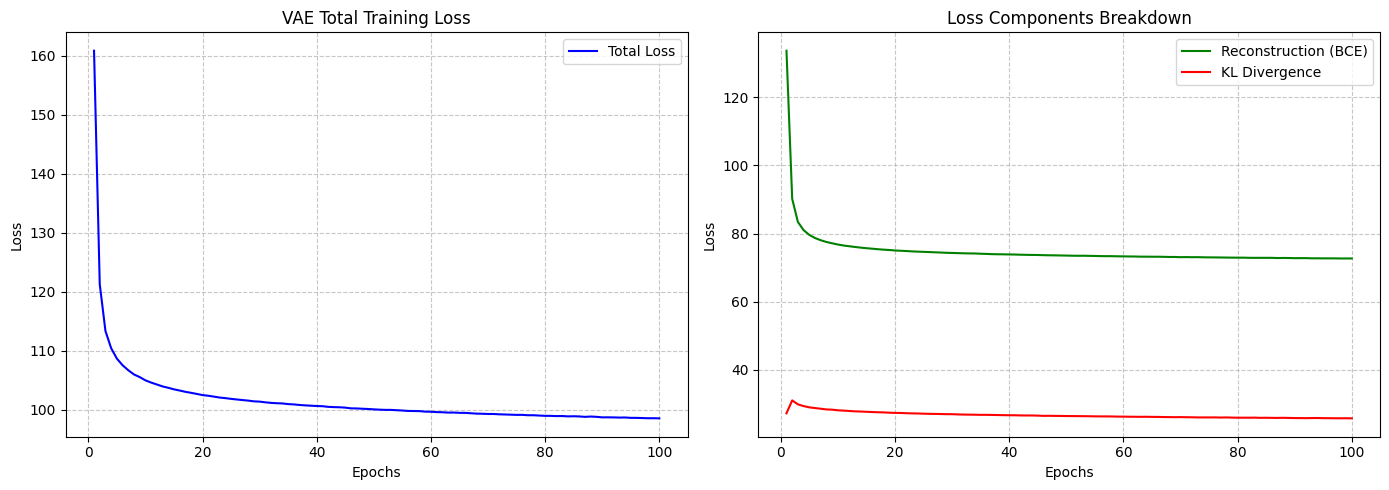

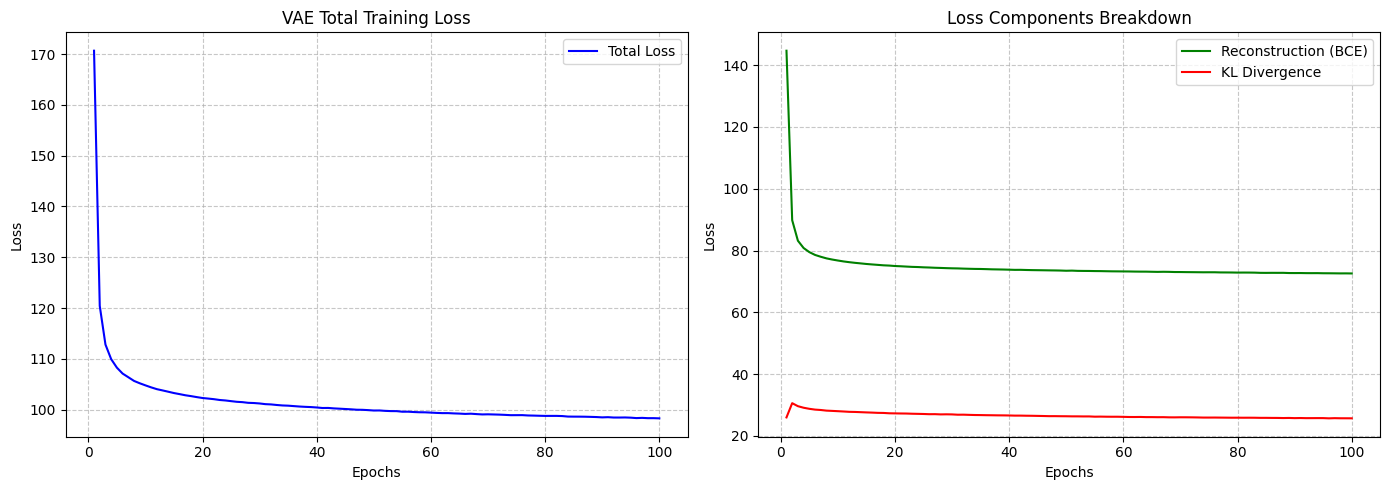

In [56]:
plot_vae_history(vae_mnist_fp["history"])
plot_vae_history(vae_mnist_mp["history"])


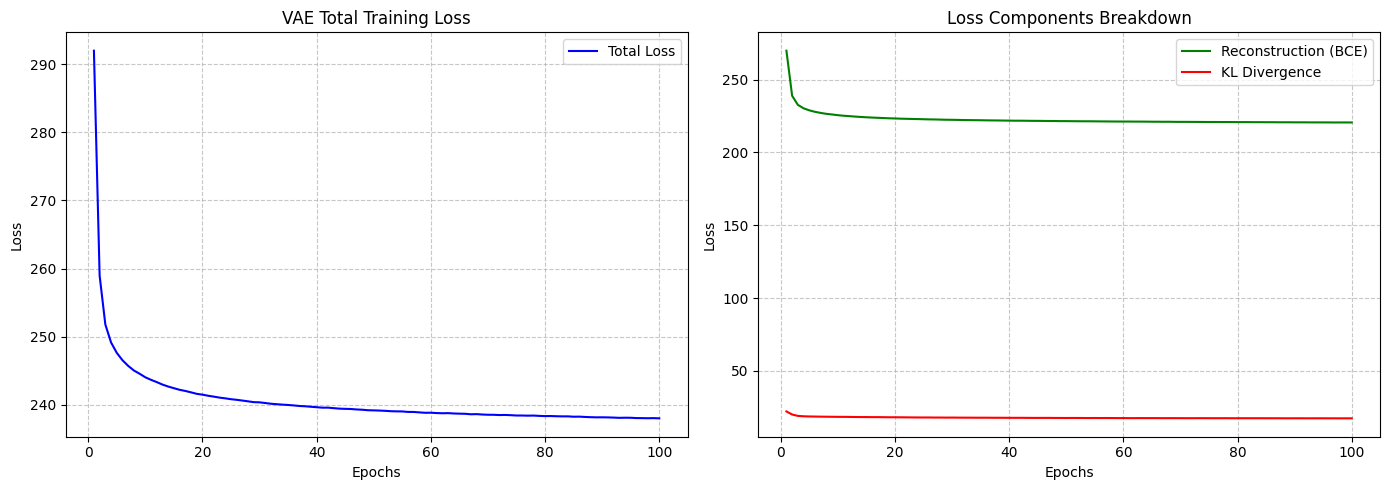

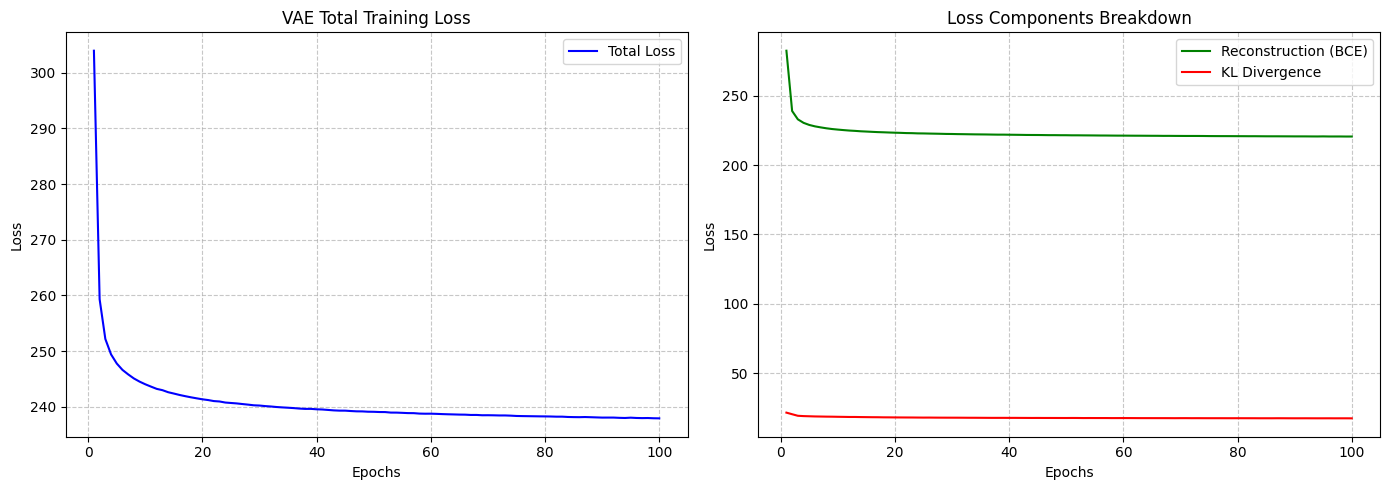

In [57]:
plot_vae_history(vae_fmnist_fp["history"])
plot_vae_history(vae_fmnist_mp["history"])


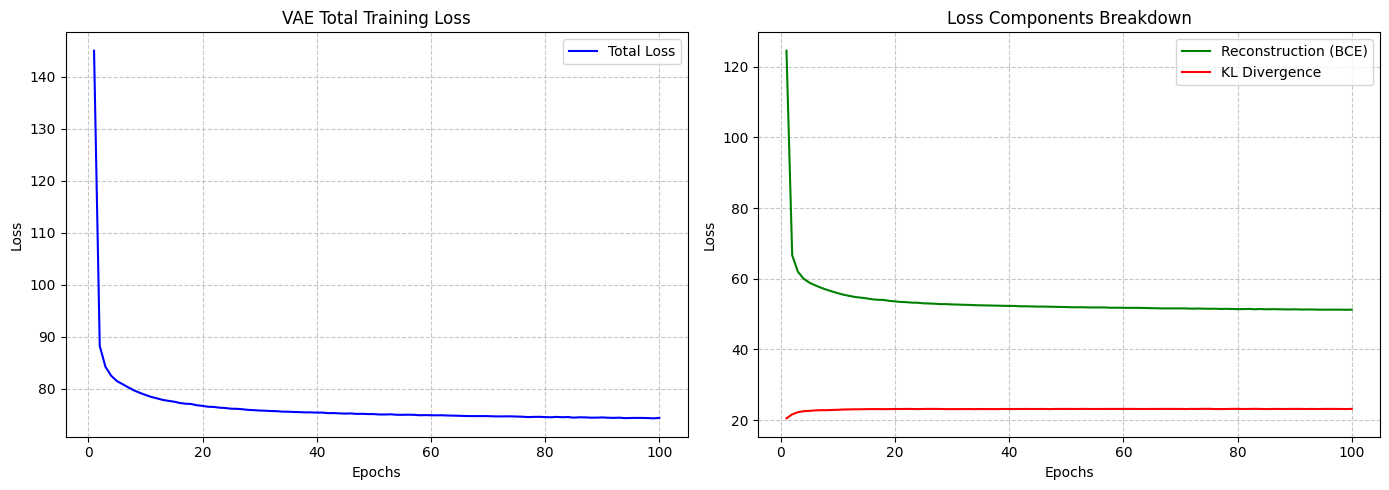

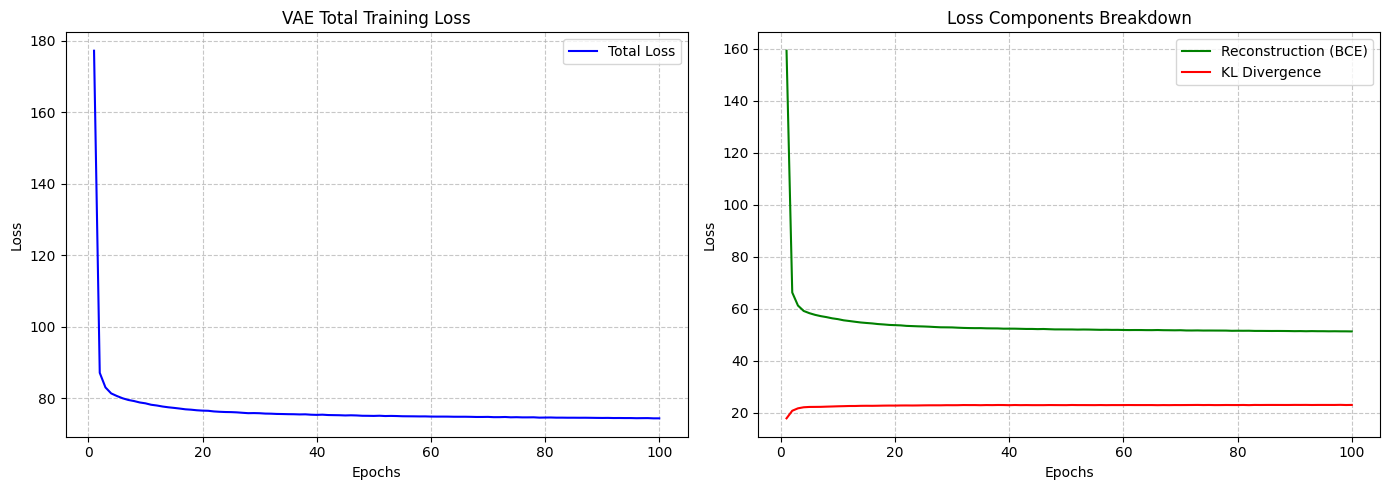

In [58]:
plot_vae_history(vae_cifar10_fp["history"])
plot_vae_history(vae_cifar10_mp["history"])


# VQ-VAE analysis functions
These are duplicates of the functions from the VAE and VQVAE notebooks

## Load VQVAE

In [45]:


def save_trained_vqvae(
    model,
    optimizer,
    history,
    save_dir="./saved_models",
    run_name="vqvae_run",
    model_config=None,
    best_model_state_dict=None,
    extra_info=None,
):
    save_dir = Path.Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = save_dir / f"{run_name}.pt"
    history_path = save_dir / f"{run_name}_history.json"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "best_model_state_dict": best_model_state_dict,
        "history": history,
        "model_config": model_config if model_config is not None else {},
        "extra_info": extra_info if extra_info is not None else {},
    }

    torch.save(checkpoint, checkpoint_path)

    # remove non-JSON-safe objects from history export
    history_json = {
        k: v for k, v in history.items()
        if k not in ["model", "optimizer"]
    }

    with open(history_path, "w") as f:
        json.dump(
            {
                "history": make_json_safe(history_json),
                "model_config": make_json_safe(model_config if model_config is not None else {}),
                "extra_info": make_json_safe(extra_info if extra_info is not None else {}),
            },
            f,
            indent=2,
        )

    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history json to: {history_path}")

    return str(checkpoint_path), str(history_path)


def load_trained_vqvae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,   # important fix
    )

    model_config = checkpoint.get("model_config", {})
    model = model_class(**model_config).to(device)

    if load_best and checkpoint.get("best_model_state_dict") is not None:
        model.load_state_dict(checkpoint["best_model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": model_config,
        "extra_info": extra_info,
    }




## Fetch VQVAE models

In [51]:
# compatibility aliases for old checkpoint class names
Encoder = EncoderVQ
Decoder = DecoderVQ

vqvae_checkpoint_path = Path(str(KAGGLE_MODEL_DIR / "VQVAE_final"/ "saved_models/VQVAE"))

vqvae_mnist_fp = load_trained_vae(
    checkpoint_path=str(vqvae_checkpoint_path/ "MNIST" / "vqvae_mnist_FP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vqvae_mnist_mp = load_trained_vae(
    checkpoint_path=str(vqvae_checkpoint_path/ "MNIST" / "vqvae_mnist_MP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vqvae_fmnist_fp = load_trained_vae(
    checkpoint_path=str(vqvae_checkpoint_path/ "FMNIST" / "vqvae_fashion_mnist_FP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vqvae_fmnist_mp = load_trained_vae(
    checkpoint_path=str(vqvae_checkpoint_path/ "FMNIST" / "vqvae_fashion_mnist_MP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vqvae_cifar10_fp = load_trained_vae(
    checkpoint_path=str(vqvae_checkpoint_path/ "CIFAR" / "vqvae_cifar10_FP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vqvae_cifar10_mp = load_trained_vae(
    checkpoint_path=str(vqvae_checkpoint_path/ "CIFAR" / "vqvae_cifar10_MP.pt"),
    model_class=VQVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)